# Monty Hall problem

### Simulate the Monty Hall Problem

- Simulate three doors, one car, and two goats.
 - Simulate three players: the switcher, the conservative, and the newcomer. 
 - Record who wins.
 - Repeat it many times.
 - Which player do you want to be?
 

**Food for thought:** And what if you had $N$ doors to choose from and the presenter opens $p\leq N$ of them? Study how the probability of winning changes as a function of $p$ and $N$.

### The guide for the code below: 

1- You can change the number of doors (d) and make sure that it is higher than k by 2 values.

2- The code is a counter. It counts wins for each player and the values are stored in the dataframe at the end.

3- Everytime you run the loop code, store the data in a different df of the following.

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt


### The best trials: 
*  k= 10
*  k= 23
*  k= 40

In [93]:
gates = []
con = []
swi = []
p3 = []
d = 50   # number of total doors
k = 10    # Number of opened doors
for n in range(3+k-1,d+1):          # number of doors to test
 conservative = 0
 switcher = 0
 player3 = 0
 for i in range(10000):        # Number of trials
 
  car = np.random.randint(1,n+1)
  choose = np.random.randint(1,n+1)
  doors = [x for x in range(1,n+1)]
  
  possible = [d for d in doors if d != car and d != choose]

  
  opened = random.sample(possible,k=k)

  for o in opened:
   doors.remove(o) 
  player3_choice = random.choice(doors)
  doors.remove(choose)            # switcher is choosing any door but not the conservative door
  switch = random.choice(doors)
 
  if (choose == car):
     conservative += 1
 
  if (switch == car):
     switcher += 1
 
  if player3_choice == car:
     player3 += 1
   
 #  print(car,choose, open,switch, doors) 
 con.append(conservative/i)
 swi.append(switcher/i)
 p3.append(player3/i)
 gates.append(n)




In [94]:
df0 = pd.DataFrame({'N_Gates':gates,'Cons_choice': con, 'Switch_choice': swi, 'Player3_choice': p3})
k0 = k
ticks_0 = [x for x in range(3+k-1,d+1,7)]

In [91]:
df1 = pd.DataFrame({'N_Gates':gates,'Cons_choice': con, 'Switch_choice': swi, 'Player3_choice': p3})
k1 = k
ticks_1 = [x for x in range(3+k-1,d+1,5)]

In [88]:
df2 = pd.DataFrame({'N_Gates':gates,'Cons_choice': con, 'Switch_choice': swi, 'Player3_choice': p3})
k2= k
ticks_2 = [x for x in range(3+k-1,d+1,3)]

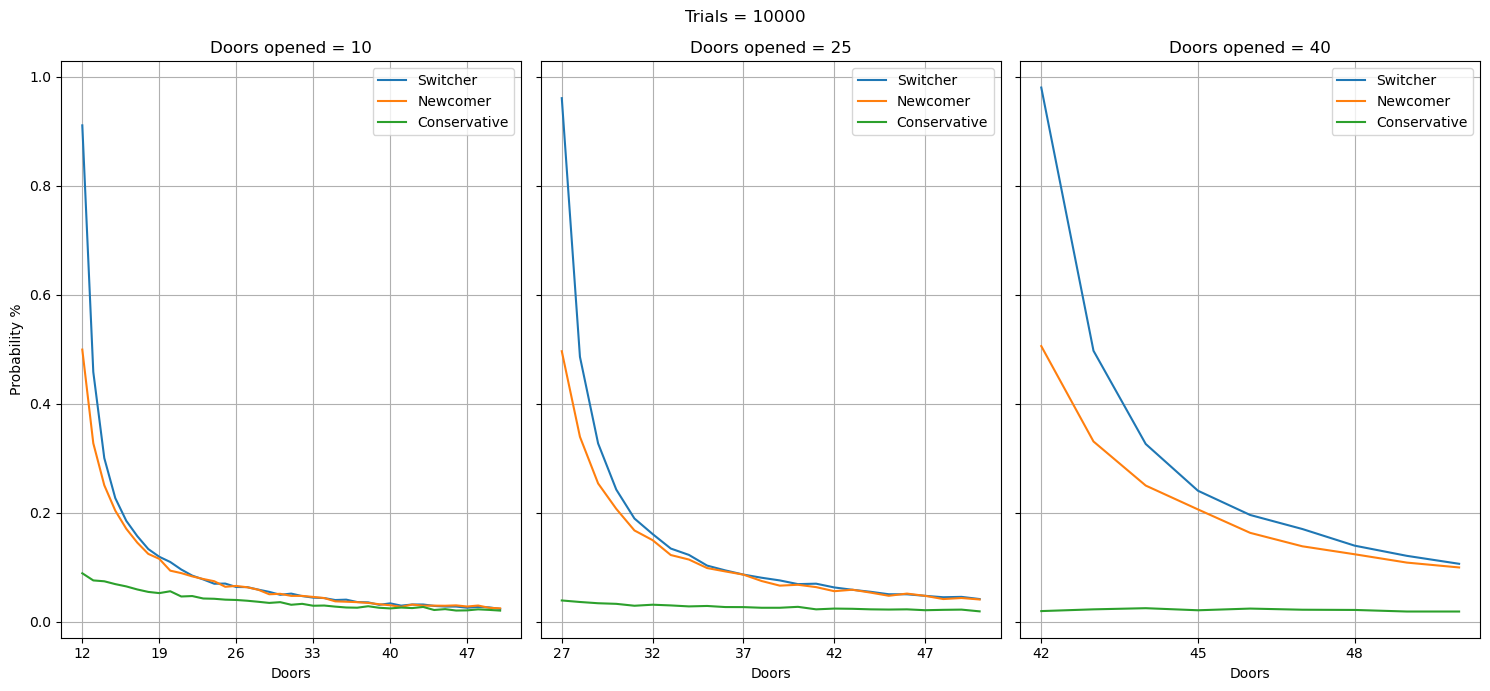

In [ ]:
fig , (ax0, ax1, ax2) = plt.subplots(1,3, figsize = (15,7), sharey= True)

ax0.plot(df0['N_Gates'],df0['Switch_choice'], label = 'Switcher')
ax0.plot(df0['N_Gates'],df0['Player3_choice'],label = 'Newcomer')
ax0.plot(df0['N_Gates'],df0['Cons_choice'], label = 'Conservative')
ax0.set_title(f'Doors opened = {k0}')
ax0.set_xlabel('Doors')
ax0.grid()
ax0.legend()
ax0.set_xticks(ticks_0)
ax0.set_ylabel('Probability')

ax1.plot(df1['N_Gates'],df1['Switch_choice'], label = 'Switcher')
ax1.plot(df1['N_Gates'],df1['Player3_choice'],label = 'Newcomer')
ax1.plot(df1['N_Gates'],df1['Cons_choice'], label = 'Conservative')
ax1.set_title(f'Doors opened = {k1}')
ax1.set_xlabel('Doors')
ax1.grid()
ax1.legend()
ax1.set_xticks(ticks_1)

ax2.plot(df2['N_Gates'],df2['Switch_choice'], label = 'Switcher')
ax2.plot(df2['N_Gates'],df2['Player3_choice'],label = 'Newcomer')
ax2.plot(df2['N_Gates'],df2['Cons_choice'], label = 'Conservative')
ax2.set_title(f'Doors opened = {k2}')
ax2.set_xlabel('Doors')
ax2.grid('grid_dash_capstyle')
ax2.legend()
ax2.set_xticks(ticks_2)

fig.suptitle('Trials = 10000')
plt.tight_layout()


plt.show()

# Just change the number of the index g for comparison.

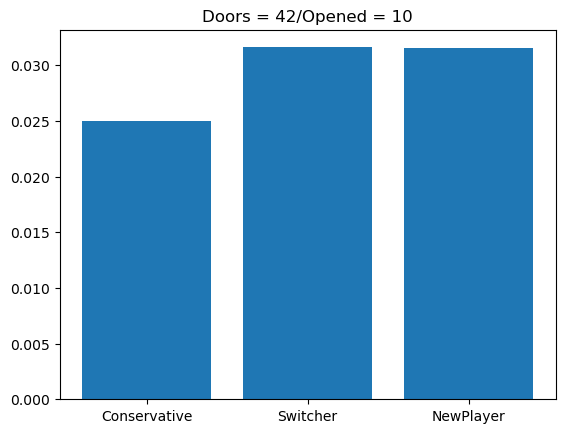

In [120]:
g = 30
titles = ['Conservative','Switcher','NewPlayer']
probabilities = [df0['Cons_choice'][g],df0['Switch_choice'][g],df0['Player3_choice'][g]]

fig, ax = plt.subplots()
ax.bar(titles, probabilities)
ax.set_title(f'Doors = {df0['N_Gates'][g]}/Opened = {k0}')
plt.show()

---
## Results:

1- The switch player has higher probabilty to win as we increase the number of trials.

2- Increasing the number of doors will make the probabilty for all of them lower and more equal number of winings. While increasing the number of trials will return the first result.



Mostly I would be the switcher.Although, if the Number of doors is very high. It won't matter much wich one unless we are closing much doors.

---
# Theoretical Work:
### Parameter Notations:
* **S = Switcher**
* **C = Conservative**
* **W = neWcomer**
* **p = opened doors**
* **N = Total Number of doors**
#### Examples:
* **P(C=1):** The probability of the Conservative winning. 
* **P(W=0)** The probability of the neWcomer losing.

### Practical Analysis Before Derivation:
  $ P(C=0) = \frac{N-1}{N} $

  $ P(C=1) = \frac{1}{N} $ 

  $ P(W=0) = \frac{N-p-1}{N-p}$ 

  $ P(W=1) = \frac{1}{N-p}$ 

  $ P(W=1|C=0) = \frac{1}{N-p-1}$

  $ P(W=0|C=1) = \frac{N-p-2}{N-p}$


## **The derivation of the probability of S = 1:**
 $ P(S=1) = P(C=0,W=1) = P(W=1|C=0)*P(C=0) $ The first trial for C loses while the W=1 depends on C lose.

 $ P(S=1) = \frac{N-1}{N(N-p-1)} $



## The derivation explanation:
* The Switcher wins in case the neWcomer choose one door which is not the conservative choice. 


### Plot of the theoratical equation which shows the same behavior:

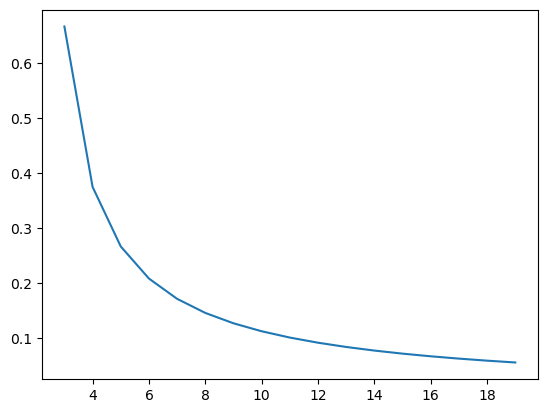

In [129]:
def P(N,p):
    return (N-1)/N/(N-p-1)
prob = [P(x,1) for x in range(3,20)]
doooo = [x for x in range(3,20)]
fig, axp = plt.subplots()
axp.plot(doooo,prob)